<a href="https://colab.research.google.com/github/rgulamali/StockPredictionPython/blob/main/XGBoostModelForNVDACopy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime

import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [3]:
# Download Dataset
current_date = datetime.now().date()

ticker = 'NVDA'
df = yf.download(ticker, start='2023-01-01', end=current_date, interval='1wk', auto_adjust=True)
df = df.reset_index()
print(df.head())
print(df.info())


[*********************100%***********************]  1 of 1 completed

Price        Date      Close       High        Low       Open      Volume
Ticker                  NVDA       NVDA       NVDA       NVDA        NVDA
0      2023-01-01  14.843335  14.994176  14.019205  14.835343  1626813000
1      2023-01-08  16.881187  16.904164  15.125040  15.267890  2240313000
2      2023-01-15  17.820194  17.854157  16.713363  16.881185  1968625000
3      2023-01-22  20.343531  20.606254  17.799217  18.044956  2632581000
4      2023-01-29  21.077761  21.925865  18.930027  19.928973  2640747000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        172 non-null    datetime64[ns]
 1   (Close, NVDA)   172 non-null    float64       
 2   (High, NVDA)    172 non-null    float64       
 3   (Low, NVDA)     172 non-null    float64       
 4   (Open, NVDA)    172 non-null    float64       
 5   (Volume, 

In [4]:
### Understanding Feature Importance
The feature importance plot generated by `xgb.plot_importance` identifies which input variables were most valuable in constructing the boosted decision trees.

*   **F-score (Weight):** By default, this plot shows the 'weight', which is the number of times a feature appears in a tree across the entire ensemble.
*   **Context:** For your NVDA price prediction, features like `Volume` or `Low` showing high importance suggests they provide the strongest signals for predicting the following week's closing price.
*   **Usage:** This helps in feature selection; if a feature has zero or very low importance, it might not be contributing much to the model's predictive power.

/tmp/ipykernel_15604/2074150497.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x_train = df.iloc[:-1].copy().drop(columns=['target_close','Date'])


Price,Date,Close,High,Low,Open,Volume,target_close
Ticker,,NVDA,NVDA,NVDA,NVDA,NVDA,
167,2026-03-15,172.699997,188.880005,171.720001,182.970001,968780300,167.520004
168,2026-03-22,167.520004,181.220001,167.009995,177.259995,875471100,177.389999
169,2026-03-29,177.389999,177.490005,164.270004,168.779999,723083500,188.630005
170,2026-04-05,188.630005,190.000000,173.660004,177.160004,664719900,189.309998
171,2026-04-12,189.309998,189.660004,185.740005,186.029999,133648200,NaN


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

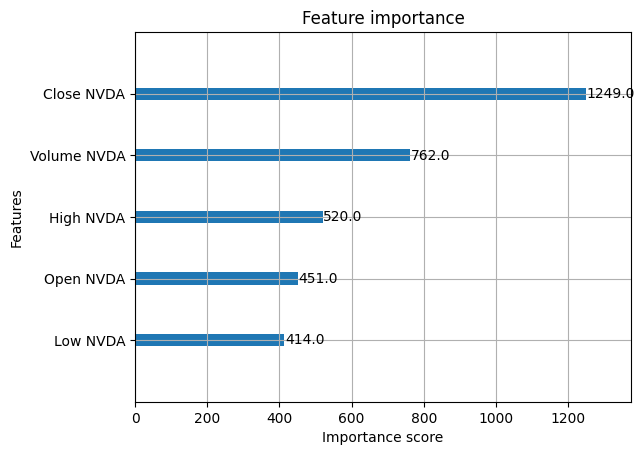

In [5]:
# Training an XGB model
reg = xgb.XGBRegressor(n_estimators=1000, random_state = 8)
reg.fit(x_train, y_train)

xgb.plot_importance(reg, max_num_features = 100)

### Interpreting the Importance Scores
The numbers on the horizontal axis (e.g., 1249, 762, 520) are **F-scores** representing the **Weight** of each feature:

1.  **Weight (Frequency):** This is the number of times a feature is used to split the data across all boosting rounds (trees).
2.  **Relative Importance:** A feature with a score of 1249 was used more than twice as often as a feature with a score of 520, suggesting it is a much more frequent 'decider' in the model's logic.
3.  **Note:** While weight shows frequency, other metrics like `gain` (average reduction in loss) or `cover` (number of samples affected) can also be used to look at importance from different angles.

In [6]:
# Simple Feature Engineering
df['ratio close to high'] = df[('Close', ticker)] / df[('High', ticker)]
df['ratio close to low'] = df[('Close', ticker)] / df[('Low', ticker)]
df['ratio open to high'] = df[('Open', ticker)] / df[('High', ticker)]
df['ratio open to low'] = df[('Open', ticker)] / df[('Low', ticker)]
df['ratio high to low'] = df[('High', ticker)] / df[('Low', ticker)]
df['SMA_5'] = df[('Close', ticker)].rolling(window=5).mean()

df.head()

Price,Date,Close,High,Low,Open,Volume,target_close,ratio close to high,ratio close to low,ratio open to high,ratio open to low,ratio high to low,SMA_5
Ticker,,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,
0,2023-01-01,14.843335,14.994176,14.019205,14.835343,1626813000,16.881187,0.989940,1.058786,0.989407,1.058216,1.069545,NaN
1,2023-01-08,16.881187,16.904164,15.125040,15.267890,2240313000,17.820194,0.998641,1.116109,0.903203,1.009445,1.117628,NaN
2,2023-01-15,17.820194,17.854157,16.713363,16.881185,1968625000,20.343531,0.998098,1.066224,0.945504,1.010041,1.068256,NaN
3,2023-01-22,20.343531,20.606254,17.799217,18.044956,2632581000,21.077761,0.987250,1.142945,0.875703,1.013806,1.157706,NaN
4,2023-01-29,21.077761,21.925865,18.930027,19.928973,2640747000,21.242584,0.961319,1.113456,0.908925,1.052770,1.158258,18.193202


/tmp/ipykernel_15604/1200707686.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x_train = df.iloc[4:-1].copy().drop(columns=['target_close','Date'])


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

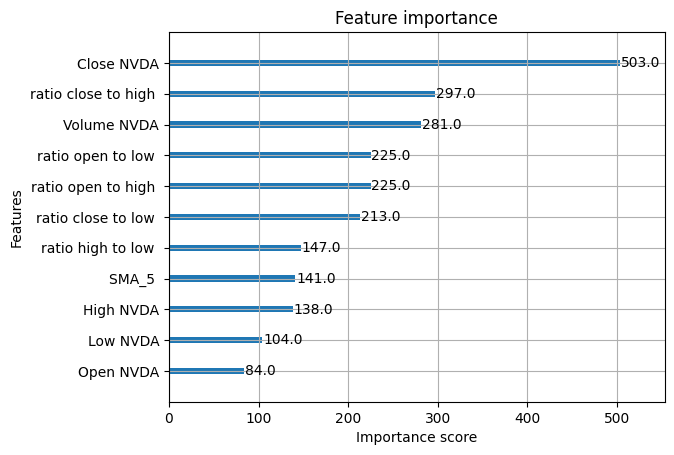

In [7]:
# Update training data with new features
x_train = df.iloc[4:-1].copy().drop(columns=['target_close','Date'])
y_train = df['target_close'][4:-1]

# Retraining the model with new features
reg.fit(x_train, y_train)

xgb.plot_importance(reg, max_num_features = 100)

In [8]:
# Predicting 1 step ahead stock price
df_pred = df.iloc[-1:]
x_pred = df_pred.drop(columns=['target_close','Date'], axis=1)
y_pred = reg.predict(x_pred)

print(f'{ticker}')
print(f'Date close of prediction : {df["Date"].iloc[-1]}')
print(f'Predicted close : {y_pred[-1]:.2f}')

NVDA
Date close of prediction : 2026-04-12 00:00:00
Predicted close : 187.28


/tmp/ipykernel_15604/206914885.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x_pred = df_pred.drop(columns=['target_close','Date'], axis=1)


In [9]:
# Preparing backtest dataset
backtest_period = -5
y_test = df['target_close'][backtest_period:-1]

# Assessing and backtesting model performance
backtest_pred = []

for i in range(backtest_period,-1,1):
  df_backtest_train = df.iloc[:i]
  x_backtest_train = df_backtest_train.drop(columns=['target_close','Date'], axis=1)
  y_backtest_train = df_backtest_train['target_close']
  x_backtest_test = df.iloc[i:i+1].drop(columns=['target_close','Date'], axis=1)
  reg.fit(x_backtest_train, y_backtest_train)
  y_pred = reg.predict(x_backtest_test)
  backtest_pred.append(y_pred)

print(f'Backtest Results for {ticker}')
print(f'MSE: {mean_squared_error(y_test, backtest_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test, backtest_pred):.2f}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, backtest_pred):.2f}')

data = {'Actual': y_test, 'Predicted': backtest_pred}
df_backtest = pd.DataFrame(data)
print(df_backtest)

/tmp/ipykernel_15604/1680997697.py:10: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x_backtest_train = df_backtest_train.drop(columns=['target_close','Date'], axis=1)
/tmp/ipykernel_15604/1680997697.py:12: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x_backtest_test = df.iloc[i:i+1].drop(columns=['target_close','Date'], axis=1)
/tmp/ipykernel_15604/1680997697.py:10: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x_backtest_train = df_backtest_train.drop(columns=['target_close','Date'], axis=1)
/tmp/ipykernel_15604/1680997697.py:12: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x_backtest_test = df.iloc[i:i+1].drop(columns=['target_close','Date'], axis=1)
/tmp/ipykernel_15604/1680997697.py:10: PerformanceWarning: dropping on a

Backtest Results for NVDA
MSE: 70.27
MAE: 7.71
MAPE: 0.04
         Actual    Predicted
167  167.520004  [171.17163]
168  177.389999  [171.72398]
169  188.630005   [176.4765]
170  189.309998  [198.68727]
